In [2]:
!pip uninstall -y transformers
!pip uninstall -y tokenizers
!pip install --no-cache-dir -U transformers datasets evaluate accelerate


Found existing installation: transformers 4.57.0
Uninstalling transformers-4.57.0:
  Successfully uninstalled transformers-4.57.0
Found existing installation: tokenizers 0.22.1
Uninstalling tokenizers-0.22.1:
  Successfully uninstalled tokenizers-0.22.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 159.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.3/506.3 kB 410.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 333.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 MB 297.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 323.7 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4

# 1. Import

In [1]:
import pandas as pd
import numpy as np
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
import evaluate
from sklearn.model_selection import train_test_split

# 2. Setup Dataset

In [2]:
import requests
import zipfile
import glob

url = f"https://drive.google.com/uc?export=download&id=1edTm4a2u_--1OMV0wmKbDMpt82EJCQMN"
r = requests.get(url)
open('dataset.zip', 'wb').write(r.content)
with zipfile.ZipFile('dataset.zip', 'r') as z:
    z.extractall('dataset')
files = glob.glob('dataset/**/*', recursive=True)
files = [f for f in files if f.endswith(('.csv','.tsv','.txt'))]
files[:20]

['dataset/sample_submission.csv', 'dataset/test.csv', 'dataset/train.csv']

In [3]:
files = glob.glob('dataset/**/*', recursive=True)
csvs = [f for f in files if f.endswith('.csv')]
if len(csvs) == 0:
    csvs = [f for f in files if f.endswith('.tsv') or f.endswith('.txt')]
path = 'dataset/train.csv'
path2 = 'dataset/test.csv'
try:
    train = pd.read_csv(path)
    test = pd.read_csv(path2)
except Exception as e:
    try:
        train = pd.read_csv(path, sep='\t')
    except Exception as e2:
        train = pd.read_csv(path, sep=';', encoding='latin1')
print('Train shape:', train.shape)
print('Test shape:', test.shape)
display(train.head())

Train shape: (586, 3)
Test shape: (146, 2)


,id,Text,Sentiment
0,1,Exploring the world of digital art. It's never...,Negative
1,2,Feeling inspired after attending a workshop.,Positive
2,3,"Eyes wide open in the night, fearful shadows d...",Negative
3,4,"A soul weathered by the storm of heartbreak, s...",Negative
4,5,"Attended a wine tasting event, savoring the ri...",Positive


# 3. EDA

/tmp/ipython-input-1797902724.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="label", data=train, palette="Set2")


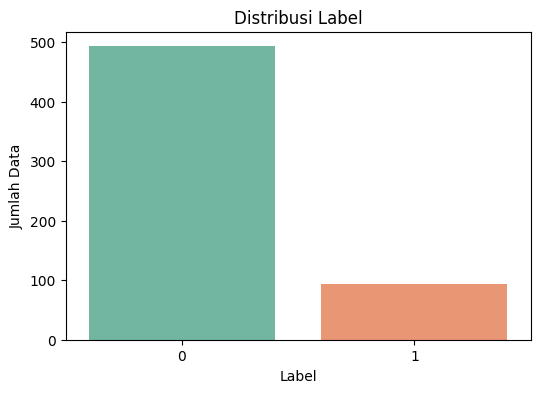

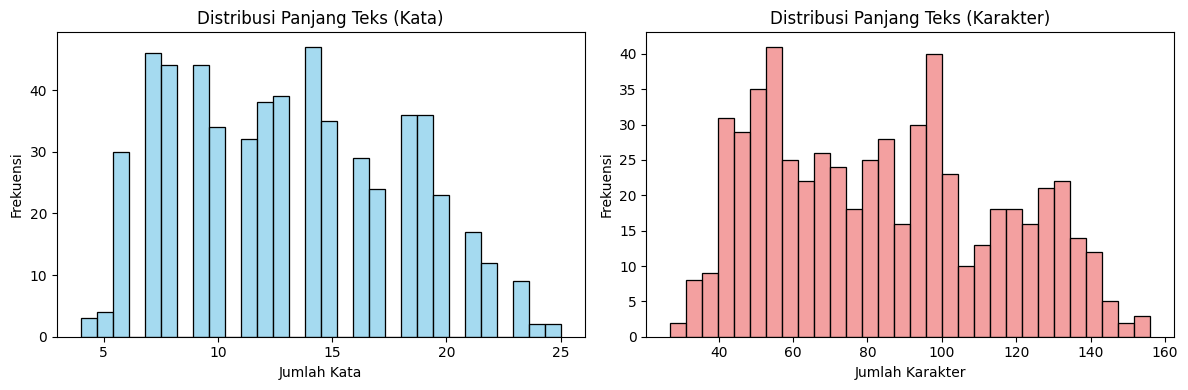


 WordCloud per Label:


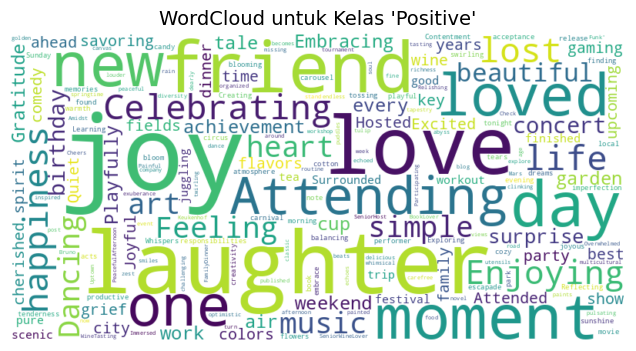

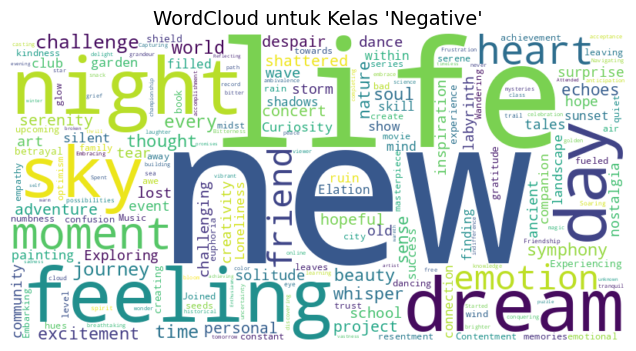

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from wordcloud import WordCloud

# Rename the 'Sentiment' column to 'label' and map string labels to integers
train = train.rename(columns={"Text": "text", "Sentiment": "label"})
label2id = {"Positive": 1, "Negative": 0}
train["label"] = train["label"].map(label2id)
train.dropna(subset=['label'], inplace=True)
train['label'] = train['label'].astype(int)

# Label Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="label", data=train, palette="Set2")
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Number of Samples")
plt.show()

if train["label"].dtype == "object":
    print("Unique labels and their counts:")
    print(train["label"].value_counts())

# Text Length
train["text_length_words"] = train["text"].apply(lambda x: len(str(x).split()))
train["text_length_chars"] = train["text"].apply(lambda x: len(str(x)))

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.histplot(train["text_length_words"], bins=30, color="skyblue")
plt.title("Text Length Distribution (Words)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
sns.histplot(train["text_length_chars"], bins=30, color="lightcoral")
plt.title("Text Length Distribution (Characters)")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# WordCloud per Label
print("\n WordCloud per Label:")
if "label2id" in globals():
    id2label = {v: k for k, v in label2id.items()}
else:
    unique_labels = train["label"].unique()
    id2label = {v: str(v) for v in unique_labels}

for label_id, label_name in id2label.items():
    subset = train[train["label"] == label_id]
    text_combined = " ".join(subset["text"].astype(str))
    if len(text_combined.strip()) > 0:
        wc = WordCloud(width=800, height=400, background_color="white", collocations=False).generate(text_combined)
        plt.figure(figsize=(8,4))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis("off")
        plt.title(f"WordCloud for '{label_name}' Class", fontsize=14)
        plt.show()
    else:
        print(f"No text available for label '{label_name}'")


# 4. Pre Processing

In [5]:
import pandas as pd
from datasets import Dataset
from sklearn.model_selection import train_test_split


if train.empty:
    print("Error: The DataFrame is empty after preprocessing.")
else:
    # Split data train
    train_df, test_df = train_test_split(train, test_size=0.2, random_state=42, stratify=train["label"])

    # Convert to HuggingFace Dataset
    train_ds = Dataset.from_pandas(train_df)
    test_ds = Dataset.from_pandas(test_df)

## Tokenisasi

In [7]:
from transformers import AutoTokenizer

models = {
    'BERT (WordPiece)': 'bert-base-multilingual-cased',
    'RoBERTa (BPE)': 'roberta-base',
    'XLM-RoBERTa (SentencePiece)': 'xlm-roberta-base',
    'DistilBERT (WordPiece)': 'distilbert-base-uncased',
    'ALBERT (SentencePiece)': 'albert-base-v2'
}

sample_texts = train["text"].head(5).tolist()

token_stats = []

for name, model_name in models.items():
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    print(f"\n==== {name} ====")
    token_lengths = []

    for text in sample_texts:
        tokens = tokenizer.tokenize(str(text))
        token_lengths.append(len(tokens))
        print(f"Sentence: {text}")
        print(f"Tokens: {tokens}\n")

    token_stats.append({
        "Model": name,
        "Avg Tokens": sum(token_lengths) / len(token_lengths),
        "Min Tokens": min(token_lengths),
        "Max Tokens": max(token_lengths),
        "Total Tokens (5 samples)": sum(token_lengths)
    })

# Token Example
token_stats_df = pd.DataFrame(token_stats)
print("\n Tokenization Summary:")
display(token_stats_df)


==== BERT (WordPiece) ====
Sentence: Exploring the world of digital art. It's never too late to discover new passions. #DigitalArtistry #LateBloomer
Tokens: ['Ex', '##ploring', 'the', 'world', 'of', 'digital', 'art', '.', 'It', "'", 's', 'never', 'too', 'late', 'to', 'discover', 'new', 'passion', '##s', '.', '#', 'Digital', '##A', '##rti', '##str', '##y', '#', 'Late', '##B', '##lo', '##ome', '##r']

Sentence: Feeling inspired after attending a workshop.
Tokens: ['Feeling', 'inspired', 'after', 'attending', 'a', 'workshop', '.']

Sentence: Eyes wide open in the night, fearful shadows dancing on the walls, the mind a prisoner of imagined horrors.
Tokens: ['Eyes', 'wide', 'open', 'in', 'the', 'night', ',', 'fear', '##ful', 'sh', '##adow', '##s', 'dancing', 'on', 'the', 'walls', ',', 'the', 'mind', 'a', 'prisoner', 'of', 'ima', '##gine', '##d', 'horror', '##s', '.']

Sentence: A soul weathered by the storm of heartbreak, seeking refuge in the calm after.
Tokens: ['A', 'soul', 'weather', '

,Model,Avg Tokens,Min Tokens,Max Tokens,Total Tokens (5 samples)
0,BERT (WordPiece),25.6,7,42,128
1,RoBERTa (BPE),22.4,8,37,112
2,XLM-RoBERTa (SentencePiece),26.0,9,43,130
3,DistilBERT (WordPiece),21.6,7,35,108
4,ALBERT (SentencePiece),21.8,7,35,109


# 5. Model Transfer Learning

In [10]:
import evaluate
import numpy as np

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")
precision_metric = evaluate.load("precision")
recall_metric = evaluate.load("recall")

# Pipeline for evaluation metric
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_metric.compute(predictions=preds, references=labels)
    f1 = f1_metric.compute(predictions=preds, references=labels, average="weighted")
    prec = precision_metric.compute(predictions=preds, references=labels, average="weighted")
    rec = recall_metric.compute(predictions=preds, references=labels, average="weighted")

    return {
        "accuracy": acc["accuracy"],
        "f1": f1["f1"],
        "precision": prec["precision"],
        "recall": rec["recall"]
    }

# Fine Tuning Model
def fine_tune(model_name, train_ds, test_ds, num_labels):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    def tokenize_fn(batch):
        return tokenizer(batch['text'], truncation=True)

    tokenized_train = train_ds.map(tokenize_fn, batched=True)
    tokenized_test = test_ds.map(tokenize_fn, batched=True)
    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)
    steps_per_epoch = len(train_ds)

    training_args = TrainingArguments(
        output_dir=f'./results/{model_name}',
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=10,
        weight_decay=0.01,
        logging_dir='./logs',
        report_to='none',
        do_eval=True,
        eval_steps=steps_per_epoch,
        logging_steps=steps_per_epoch,
        save_total_limit=1
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_train,
        eval_dataset=tokenized_test,
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    trainer.train()
    eval_result = trainer.evaluate()
    print(f'\\nEval result for {model_name}: {eval_result}')
    return model, eval_result

# 6. Train

In [11]:
num_labels = train["label"].nunique()


results = {}
for model_name in models.values():
    _, eval_result = fine_tune(model_name, train_ds, test_ds, num_labels)
    results[model_name] = eval_result

Map:   0%|          | 0/468 [00:00<?, ? examples/s]

Map:   0%|          | 0/118 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4052853036.py:52: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
468,0.160700


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


...

model.safetensors:   0%|          | 0.00/47.4M [00:00<?, ?B/s]

Some weights of AlbertForSequenceClassification were not initialized from the model checkpoint at albert-base-v2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4052853036.py:52: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss
468,0.189900


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


\nEval result for albert-base-v2: {'eval_loss': 0.3354759216308594, 'eval_accuracy': 0.923728813559322, 'eval_f1': 0.9228897579975001, 'eval_precision': 0.9222693032015067, 'eval_recall': 0.923728813559322, 'eval_runtime': 8.7872, 'eval_samples_per_second': 13.429, 'eval_steps_per_second': 1.707, 'epoch': 10.0}


# 7. Hasil Perbandingan

In [12]:
import pandas as pd
pd.DataFrame(results).T

,eval_loss,eval_accuracy,eval_f1,eval_precision,eval_recall,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch
bert-base-multilingual-cased,0.446104,0.932203,0.932203,0.932203,0.932203,9.5864,12.309,1.565,10.0
roberta-base,0.415194,0.940678,0.940025,0.939605,0.940678,8.2572,14.291,1.817,10.0
xlm-roberta-base,0.264738,0.940678,0.942392,0.945926,0.940678,9.9213,11.894,1.512,10.0
distilbert-base-uncased,0.306458,0.940678,0.938578,0.938746,0.940678,4.1775,28.246,3.591,10.0
albert-base-v2,0.335476,0.923729,0.922890,0.922269,0.923729,8.7872,13.429,1.707,10.0
